# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
267,0.059871,-0.044642,-0.000817,-0.084856,0.075484,0.079478,0.004460,0.034309,0.023371,0.027917,115.0
312,-0.074533,-0.044642,-0.023451,-0.005670,-0.020832,-0.014153,0.015505,-0.039493,-0.038460,-0.030072,144.0
331,0.081666,0.050680,-0.025607,-0.036656,-0.070367,-0.046407,-0.039719,-0.002592,-0.041176,-0.005220,199.0
290,0.059871,0.050680,0.076786,0.025315,0.001183,0.016849,-0.054446,0.034309,0.029935,0.044485,332.0
278,0.067136,0.050680,-0.036385,-0.084856,-0.007073,0.019667,-0.054446,0.034309,0.001148,0.032059,102.0
373,-0.074533,-0.044642,-0.010517,-0.005670,-0.066239,-0.057054,-0.002903,-0.039493,-0.042571,-0.001078,168.0
329,-0.012780,0.050680,-0.055785,-0.002228,-0.027712,-0.029184,0.019187,-0.039493,-0.017056,0.044485,135.0
317,0.019913,-0.044642,-0.034229,0.055165,0.067229,0.074155,-0.006584,0.032833,0.024730,0.069338,190.0
181,0.048974,-0.044642,-0.042852,-0.053870,0.045213,0.050042,0.033914,-0.002592,-0.025953,-0.063209,64.0
291,0.074401,-0.044642,0.018584,0.063187,0.061725,0.042840,0.008142,-0.002592,0.058038,-0.059067,248.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
#Este codigo devuelve booleanos "True" en las casillas donde hay valores faltantes y al final suma esos valores faltante para mostrarlos en el DF.
data.isna().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
df_simple = data.copy()
imputer = SimpleImputer(strategy='mean')
df_simple['bmi'] = imputer.fit_transform(df_simple[['bmi']])

In [8]:
df_simple.isna().sum()

age        0
sex        0
bmi        0
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:
df_knn = data.copy()

knn_imputer = KNNImputer(n_neighbors=2)

df_knn[['bmi', 'bp']] = knn_imputer.fit_transform(
    df_knn[['bmi', 'bp']]
)


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

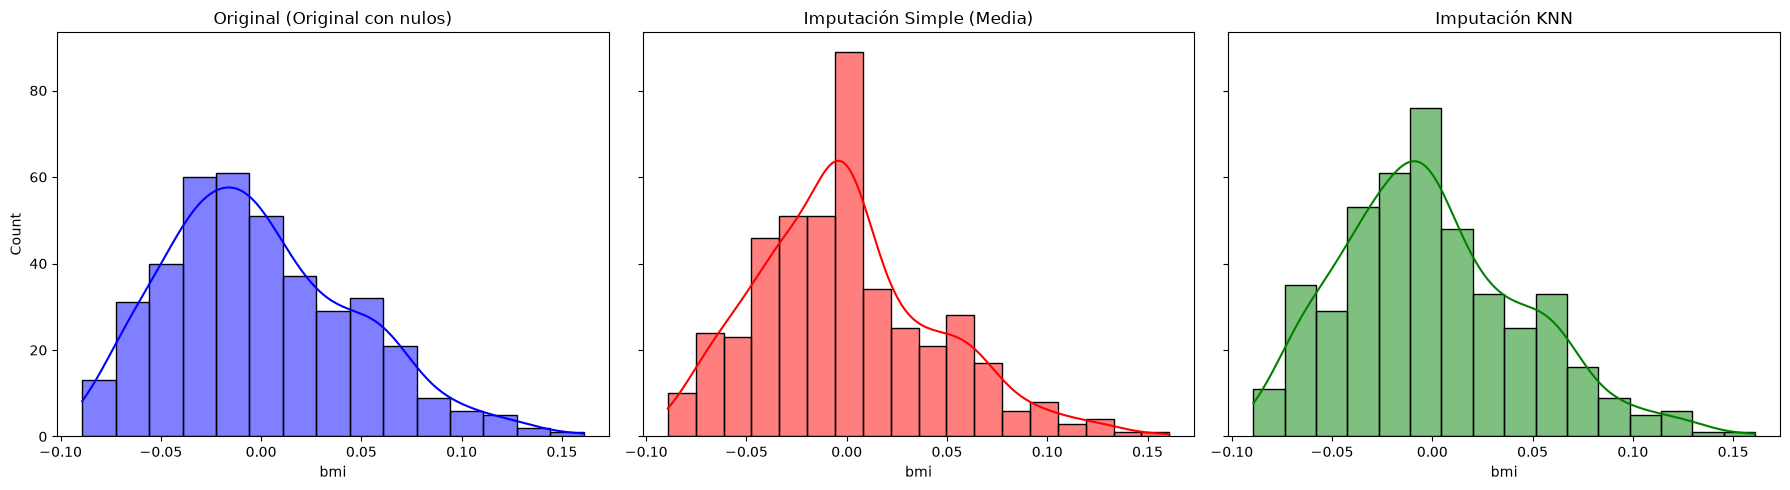

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.histplot(data['bmi'].dropna(), ax=axes[0], color='blue', kde=True)
axes[0].set_title('Original (Original con nulos)')
sns.histplot(df_simple['bmi'], ax=axes[1], color='red', kde=True)
axes[1].set_title('Imputación Simple (Media)')
sns.histplot(df_knn['bmi'], ax=axes[2], color='green', kde=True)
axes[2].set_title('Imputación KNN')

plt.tight_layout()
plt.show()